In [ ]:
import sys
import pickle
from pathlib import Path
from addict import Dict as Adict
import pandas as pd
import seaborn as sns
import mdtraj as md
from natsort import natsorted
import matplotlib.pyplot as plt

sys.path.insert(0, '/home/rzhu/Desktop/projects/kinase_analysis/src/')
from funcs_featurise import *
from funcs_db_assign import *
from funcs_indices import *
from funcs_plotting import *
from TrajData import TrajData
from MSMStudy import MSMStudy

from deeptime.markov.msm import BayesianMSM
from deeptime.plots.chapman_kolmogorov import plot_ck_test

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['pdf.compression'] = 0
plt.rcParams['image.composite_image'] = False
plt.rcParams['font.family'] = 'sans-serif'

In [2]:
model_dir = Path('/home/rzhu/Desktop/projects/kinase_analysis/data/abl/msm/')
fig_dir = Path('/home/rzhu/Desktop/projects/kinase_analysis/notebooks/manuscript/SI_cktest/')

In [3]:
def read_pickle(path):
    with open(path, 'rb') as handle:
        return pickle.load(handle)

In [4]:
test_model = read_pickle(model_dir/'scan_lags'/'11'/'models'/'bayesian_msm_model.pkl')
models = [read_pickle(model_dir/'cktest'/'4'/'models'/'bayesian_msm_model.pkl'),
          read_pickle(model_dir/'cktest'/'3'/'models'/'bayesian_msm_model.pkl'),
          read_pickle(model_dir/'cktest'/'2'/'models'/'bayesian_msm_model.pkl'),
          read_pickle(model_dir/'cktest'/'1'/'models'/'bayesian_msm_model.pkl'),
]

/home/rzhu/Loc/miniconda3/envs/msm/lib/python3.11/site-packages/deeptime/base.py:116: UserWarning: Trying to unpickle estimator TransitionCountModel from version 0.4.4 when using version 0.4.5. This might lead to breaking code or invalid results. Use at your own risk.
  warnings.warn(
/home/rzhu/Loc/miniconda3/envs/msm/lib/python3.11/site-packages/deeptime/base.py:116: UserWarning: Trying to unpickle estimator MarkovStateModelCollection from version 0.4.4 when using version 0.4.5. This might lead to breaking code or invalid results. Use at your own risk.
  warnings.warn(
/home/rzhu/Loc/miniconda3/envs/msm/lib/python3.11/site-packages/deeptime/base.py:116: UserWarning: Trying to unpickle estimator MarkovStateModel from version 0.4.4 when using version 0.4.5. This might lead to breaking code or invalid results. Use at your own risk.
  warnings.warn(


/home/rzhu/Loc/miniconda3/envs/msm/lib/python3.11/site-packages/deeptime/base.py:116: UserWarning: Trying to unpickle estimator BayesianMSMPosterior from version 0.4.4 when using version 0.4.5. This might lead to breaking code or invalid results. Use at your own risk.
  warnings.warn(


In [5]:
ck_test = test_model.ck_test(models, n_metastable_sets=6, err_est =True)

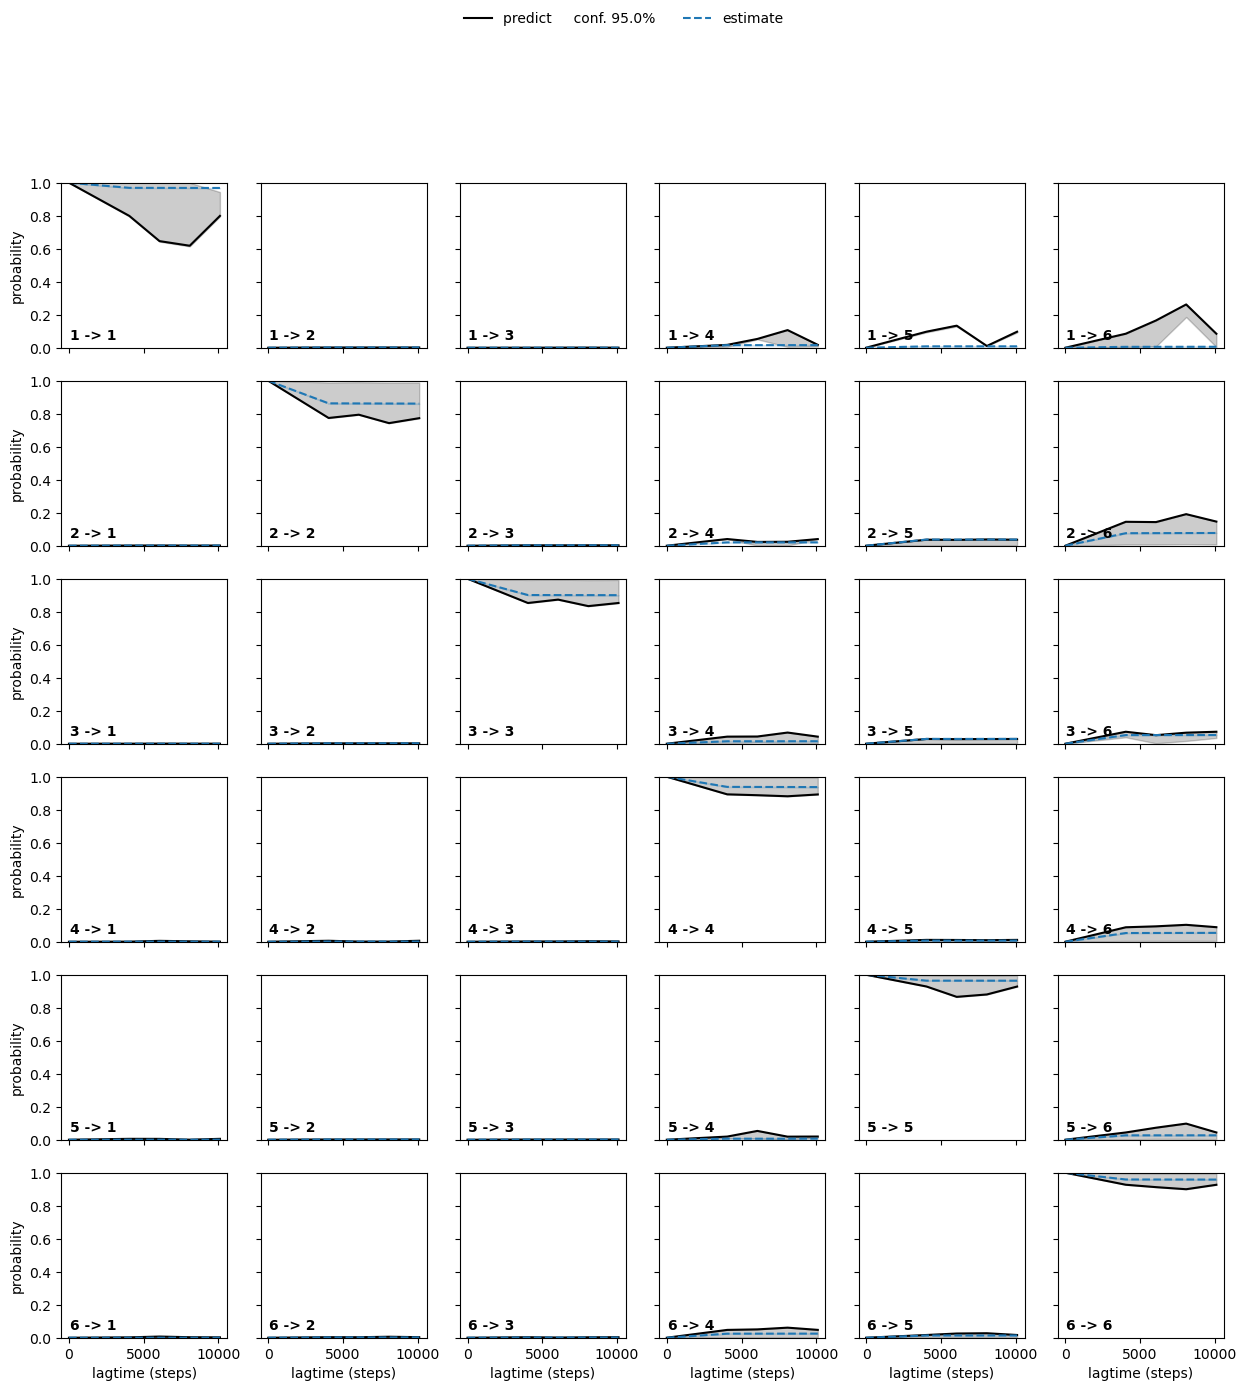

In [6]:
ck_grid = plot_ck_test(ck_test, legend=True)
fig = ck_grid.figure

In [ ]:
for ax in fig.axes:
    ax.set_rasterized(False)
    for artist in ax.get_children():
        if hasattr(artist, 'set_rasterized'):
            artist.set_rasterized(False)

out_path = fig_dir / 'SI_abl_cktest.pdf'
fig.savefig(out_path, format='pdf', bbox_inches='tight', transparent=True)
print(f'Saved {out_path}')

Saved /home/rzhu/Desktop/projects/kinase_analysis/notebooks/manuscript/SI_cktest/SI_abl_cktest.pdf
